# Segmentation with Cellpose

Adapted from the [Cellpose 3 example notebook](https://github.com/MouseLand/cellpose/blob/main/notebooks/run_cellpose3.ipynb).

StarDist describes every object as a star-convex polygon. That fits a nucleus well, but
not a cell with protrusions.

[Cellpose](https://github.com/MouseLand/cellpose) works differently. For every pixel the
network predicts an arrow pointing towards the centre of the object that pixel belongs
to. Pixels whose arrows lead to the same centre form one object. Nothing there assumes a
shape, so Cellpose can segment objects of any outline.

Two things need to be right: which model we pick, and what we tell Cellpose about the
size of our objects.

## Libraries

In [1]:
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np
import skimage as sk

from cellpose import models
from stardist import random_label_cmap

# Use a library with additional lookup tables
import colorcet as cc


We have set up Cellpose to run on the CPU, not on the GPU. For the images in this notebook that is fine.
We also use Cellpose version 3. Version 4 uses a very different architecture, which is more demanding and works best on a GPU.

# Part 1: cells with two channels

We start with a HeLa image (example image from ImageJ) that has a cytoplasmic and a nuclear channel, the situation
the `cyto3` model was built for.

(512, 672, 3)


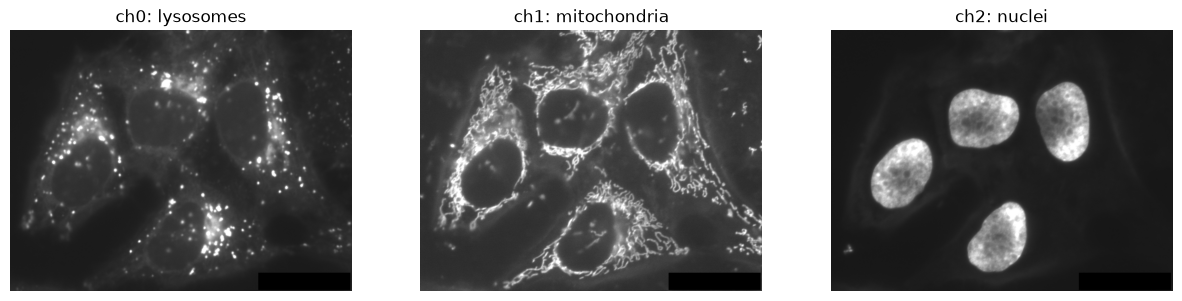

In [2]:
hela = tiff.imread("data/hela_cells.tif")
print(hela.shape)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, name in enumerate(["ch0: lysosomes", "ch1: mitochondria", "ch2: nuclei"]):
    _ = axs[i].imshow(hela[..., i], cmap="gray", vmax=np.percentile(hela[..., i], 99.5))
    _ = axs[i].set_title(name)
    _ = axs[i].axis("off")

Cellpose needs to know which channel shows the object to segment and which shows the
nucleus: `channels=[cytoplasm, nucleus]`, where 0 = grayscale, 1 = red, 2 = green,
3 = blue.

Our image is already RGB: the mitochondria (green), which fill the cytoplasm nicely, and
the nuclei (blue). So we ask for `channels=[2, 3]`.

In [3]:
model_cyto = models.CellposeModel(model_type="cyto3")
masks_hela, flows, styles = model_cyto.eval(hela, channels=[2, 3])

print(f"found {masks_hela.max()} cells")

_script.py (365): `torch.jit.script_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
dynamics.py (760): Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/Context.cpp:848.)


found 8 cells


`eval()` returns the label image, the predicted flows, and an internal summary of the
image (`styles`). Let us look at the result — there are four cells in this image.

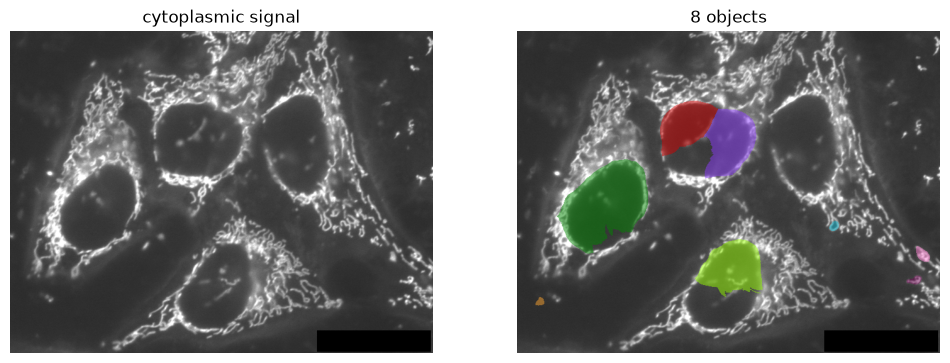

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

_ = axs[0].imshow(hela[..., 1], cmap="gray", vmax=np.percentile(hela[..., 1], 99.5))
_ = axs[0].set_title("cytoplasmic signal")

hela_labels_masked = np.ma.masked_where(masks_hela == 0, masks_hela)

_ = axs[1].imshow(hela[..., 1], cmap="gray", vmax=np.percentile(hela[..., 1], 99.5))
_ = axs[1].imshow(hela_labels_masked, cmap=cc.cm.glasbey_bw, alpha=0.5, vmax=255)

_ = axs[1].set_title(f"{masks_hela.max()} objects")
for ax in axs:
    _ = ax.axis("off")

## Setting the diameter

Cellpose works internally at a fixed object size of about 30 pixels: before running the
network it rescales the image so that objects of `diameter` pixels become 30. We did not
pass a `diameter`, so it used the model's default of 30 — while these cells are well
over a hundred pixels across. The result is a very bad segmentation.

The cells here are roughly 200 pixels wide, so let us say so.

found 4 cells


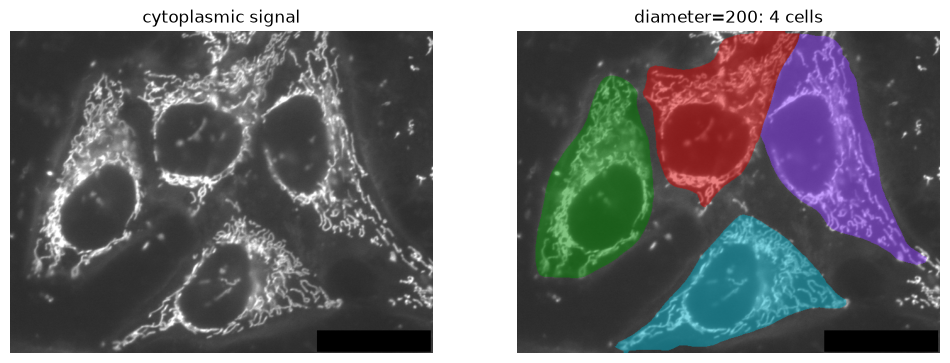

In [16]:
masks_hela, flows, _ = model_cyto.eval(hela, channels=[2, 3], diameter=200)

print(f"found {masks_hela.max()} cells")

hela_labels_masked = np.ma.masked_where(masks_hela == 0, masks_hela)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
_ = axs[0].imshow(hela[..., 1], cmap="gray", vmax=np.percentile(hela[..., 1], 99.5))
_ = axs[0].set_title("cytoplasmic signal")
_ = axs[1].imshow(hela[..., 1], cmap="gray", vmax=np.percentile(hela[..., 1], 99.5))
_ = axs[1].imshow(hela_labels_masked, cmap=cc.cm.glasbey_bw, alpha=0.5,vmax=255)
_ = axs[1].set_title(f"diameter=200: {masks_hela.max()} cells")
for ax in axs:
    _ = ax.axis("off")

This is the same parameter as StarDist's `scale`, asked the other way round: there we
said how much to shrink the image, here we say how big the objects are.

Cellpose can also show what the network predicted. The panels show the input image, the
outlines of the cells, the predicted flows (the colour shows the direction the pixels point
to) and the cells found on top of the image.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..4095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..4095].


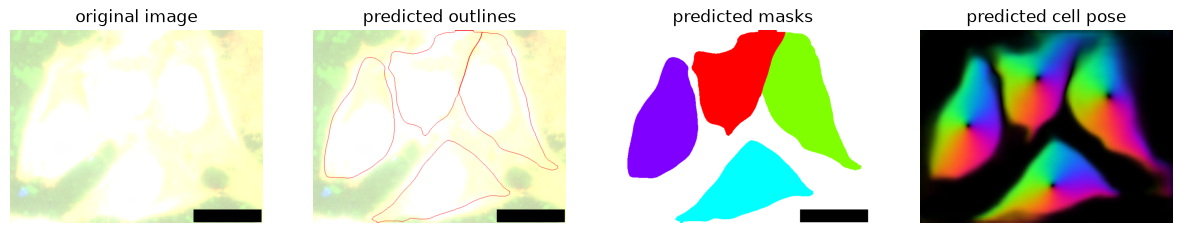

In [7]:
from cellpose import plot

fig = plt.figure(figsize=(15, 5))
plot.show_segmentation(fig, hela, masks_hela, flows[0], channels=[2, 3])

# Part 2: nuclei of the DNA damage assay

Now the image from the StarDist notebook: the nuclei channel of the irradiated cells.
There is only one channel, so we ask Cellpose to treat it as grayscale with
`channels=[0, 0]`.

In [8]:
img = tiff.imread("data/MAX_2h_IR_Position002.tif")
img_nuclei = img[1, :, :]

masks_cyto, _, _ = model_cyto.eval(img_nuclei, channels=[0, 0])
print(f"cyto3: {masks_cyto.max()} objects")

cyto3: 90 objects


## The nuclei model

`cyto3` is trained to find cells, and a nucleus is not a cell. Cellpose ships a separate
`nuclei` model for exactly this case.

In [9]:
model_nuc = models.CellposeModel(model_type="nuclei")
masks_nuc_default, _, _ = model_nuc.eval(img_nuclei, channels=[0, 0])

print(f"nuclei model: {masks_nuc_default.max()} objects")

nuclei model: 55 objects


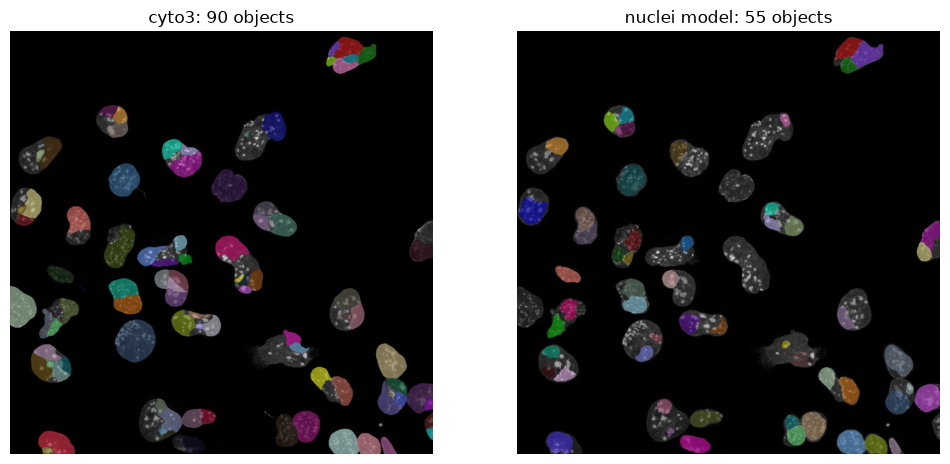

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
_ = axs[0].imshow(img_nuclei, cmap="gray")

masks_cyto_masked = np.ma.masked_where(masks_cyto == 0, masks_cyto)
_ = axs[0].imshow(masks_cyto_masked, cmap=cc.cm.glasbey_bw, alpha=0.5,vmax=255)
_ = axs[0].set_title(f"cyto3: {masks_cyto.max()} objects")

masks_nuc_default_masked = np.ma.masked_where(masks_nuc_default == 0, masks_nuc_default)

_ = axs[1].imshow(img_nuclei, cmap="gray")
_ = axs[1].imshow(masks_nuc_default_masked, cmap=cc.cm.glasbey, alpha=0.5, vmax=255)
_ = axs[1].set_title(f"nuclei model: {masks_nuc_default.max()} objects")
for ax in axs:
    _ = ax.axis("off")

The `nuclei` model is maybe a better choice, but it still does not properly segment the nuclei:
several nuclei are split in two or are missed out. We have not told it how big our
nuclei are.

In [13]:
masks_nuclei, _, _ = model_nuc.eval(img_nuclei, channels=[0, 0], diameter=80)
print(f"nuclei model with diameter=80: {masks_nuclei.max()} nuclei")

# Check afterwards how big the objects we found actually are
props = sk.measure.regionprops(masks_nuclei)
print(f"median diameter of those objects: {np.median([p.equivalent_diameter_area for p in props]):.0f} pixels")

nuclei model with diameter=80: 35 nuclei
median diameter of those objects: 77 pixels


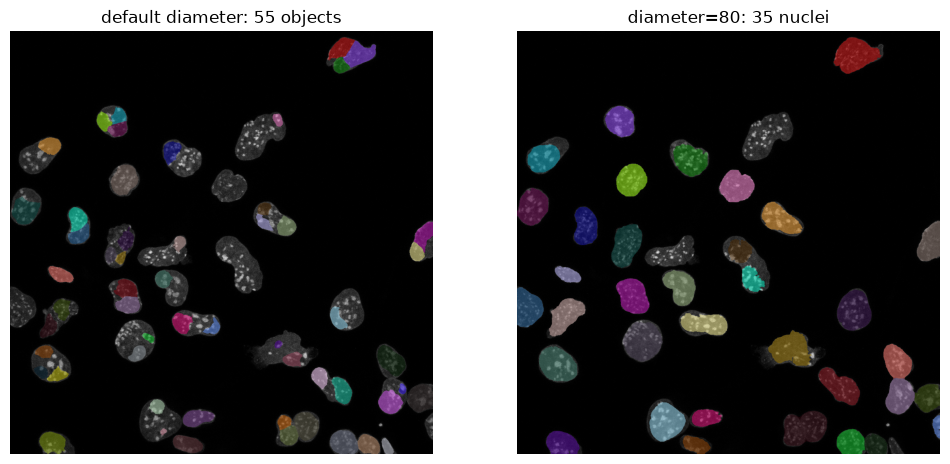

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

masks_nuc_default_masked = np.ma.masked_where(masks_nuc_default == 0, masks_nuc_default)

_ = axs[0].imshow(img_nuclei, cmap="gray")
_ = axs[0].imshow(masks_nuc_default_masked, cmap=cc.cm.glasbey_bw, alpha=0.5,vmax=255)
_ = axs[0].set_title(f"default diameter: {masks_nuc_default.max()} objects")

masks_nuclei_masked = np.ma.masked_where(masks_nuclei == 0, masks_nuclei)

_ = axs[1].imshow(img_nuclei, cmap="gray")
#_ = axs[1].imshow(masks_nuclei_masked, cmap=cc.cm.glasbey, alpha=0.5)
_ = axs[1].imshow(masks_nuclei_masked, cmap=cc.cm.glasbey_bw, alpha=0.5,vmax=255)

_ = axs[1].set_title(f"diameter=80: {masks_nuclei.max()} nuclei")
for ax in axs:
    _ = ax.axis("off")

Some nuclei are still not detected. We have a few parameters we can tune.

**flow_threshold**, default 0.4

For each mask, Cellpose compares the flows the mask implies with the flows the network predicted. Masks with a larger error than the threshold are thrown away.

- Up (e.g. 0.6–1.0): the check gets looser, so fewer masks are rejected. You get more objects, but some of them are badly shaped.
- Down (e.g. 0.2): the check gets stricter. You keep only clean, well-shaped objects, but miss more.
- 0 turns the check off completely.

**cellprob_threshold**, default 0.0

Pixels whose cell probability is above this value count as part of an object. Useful range is about -6 to 6.

- Down (e.g. -2): more pixels count as object. Dim objects get detected and masks become larger. Too low and background turns into objects or neighbours merge.
- Up (e.g. 2): fewer pixels count. Masks become smaller and only bright, confident objects remain. Dim nuclei get missed.

## Exercise: What happens when you change the diameter?

Run the `nuclei` model on `img_nuclei` with `diameter` set to 30, 60, 80 and 120, and
compare the counts and the overlays.

- What goes wrong when the diameter is too small, and what when it is too large?

## Exercise: Do StarDist and Cellpose find the same nuclei?

Redo the StarDist prediction here (it takes a few seconds) and put the two results next
to each other.

- How many nuclei does each of them find?
- Looking at the overlays, where do they disagree?

# Next

We can now segment nuclei with two very different pretrained models. In the last notebook
we detect the DNA damage foci with **Spotiflow** and combine them with these nuclei, to
count foci per cell.